In [31]:
### set up the notebook
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import scipy.signal

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
np.set_printoptions(linewidth=100) 

plt.rcParams.update({'font.size': 14})

In [32]:
### load the data

ACCESS = xr.open_dataset('../data_to_publish/ACCESS_at_buoys_FSP.nc')
GNSS = xr.open_dataset('../data_to_publish/GNSS_hourly.nc')


In [33]:
### Reindex all to common time period

new_time = np.arange(np.datetime64('2023-04-01T00:00:00'), np.datetime64('2023-07-01T00:00:00'), np.timedelta64(1, 'h'))

GNSS = GNSS.reindex(time=new_time, method='nearest', tolerance='10 min')
ACCESS = ACCESS.reindex(time=new_time, method='nearest', tolerance='10 min')

In [34]:
### convert from meters to cm and save in array

GNSS = GNSS*100
ACCESS = ACCESS*100

GNSS = np.vstack((GNSS.sn40.values,
                  GNSS.sn20.values, 
                  GNSS.sn06.values, 
                  GNSS.ss05.values, 
                  GNSS.ss20.values, 
                  GNSS.ss30.values, 
                  GNSS.ss40.values, 
                  GNSS.swxt.values, 
                  GNSS.sext.values))

ACCESS = np.vstack((ACCESS.sn40.values,
                    ACCESS.sn20.values,
                    ACCESS.sn06.values,
                    ACCESS.ss05.values,
                    ACCESS.ss20.values,
                    ACCESS.ss30.values,
                    ACCESS.ss40.values,
                    ACCESS.swxt.values,
                    ACCESS.sext.values))

In [37]:
### PSD calculation

# remove median from each time series and replace NaNs with 0
for i in range(9):
    GNSS[i,:] = GNSS[i,:] - np.nanmedian(GNSS[i,:])
    ACCESS[i,:] = ACCESS[i,:] - np.nanmedian(ACCESS[i,:])
    
    GNSS[i,:] = np.nan_to_num(GNSS[i,:])
    ACCESS[i,:] = np.nan_to_num(ACCESS[i,:])
    
# calculate PSD for each site using the welch method

sam_int = 1  # hours

# G_ for GNSS
G_freq_sn40, G_psd_sn40 = scipy.signal.welch(GNSS[0, :], fs=1/sam_int, scaling='density')
G_freq_sn20, G_psd_sn20 = scipy.signal.welch(GNSS[1, :], fs=1/sam_int, scaling='density')
G_freq_sn06, G_psd_sn06 = scipy.signal.welch(GNSS[2, :], fs=1/sam_int, scaling='density')
G_freq_ss05, G_psd_ss05 = scipy.signal.welch(GNSS[3, :], fs=1/sam_int, scaling='density')
G_freq_ss20, G_psd_ss20 = scipy.signal.welch(GNSS[4, :], fs=1/sam_int, scaling='density')
G_freq_ss30, G_psd_ss30 = scipy.signal.welch(GNSS[5, :], fs=1/sam_int, scaling='density')
G_freq_ss40, G_psd_ss40 = scipy.signal.welch(GNSS[6, :], fs=1/sam_int, scaling='density')
G_freq_swxt, G_psd_swxt = scipy.signal.welch(GNSS[7, :], fs=1/sam_int, scaling='density')
G_freq_sext, G_psd_sext = scipy.signal.welch(GNSS[8, :], fs=1/sam_int, scaling='density')

# A_ for ACCESS
A_freq_sn40, A_psd_sn40 = scipy.signal.welch(ACCESS[0, :], fs=1/sam_int, scaling='density')
A_freq_sn20, A_psd_sn20 = scipy.signal.welch(ACCESS[1, :], fs=1/sam_int, scaling='density')
A_freq_sn06, A_psd_sn06 = scipy.signal.welch(ACCESS[2, :], fs=1/sam_int, scaling='density')
A_freq_ss05, A_psd_ss05 = scipy.signal.welch(ACCESS[3, :], fs=1/sam_int, scaling='density')
A_freq_ss20, A_psd_ss20 = scipy.signal.welch(ACCESS[4, :], fs=1/sam_int, scaling='density')
A_freq_ss30, A_psd_ss30 = scipy.signal.welch(ACCESS[5, :], fs=1/sam_int, scaling='density')
A_freq_ss40, A_psd_ss40 = scipy.signal.welch(ACCESS[6, :], fs=1/sam_int, scaling='density')
A_freq_swxt, A_psd_swxt = scipy.signal.welch(ACCESS[7, :], fs=1/sam_int, scaling='density')
A_freq_sext, A_psd_sext = scipy.signal.welch(ACCESS[8, :], fs=1/sam_int, scaling='density')

# the frequency arrays are all the same, so save freq and take the mean across sites for each
freq = G_freq_sn40
GNSS_psd = np.nanmean([G_psd_sn40, G_psd_sn20, G_psd_sn06, G_psd_ss05, G_psd_ss20, G_psd_ss30, G_psd_ss40, G_psd_swxt, G_psd_sext], axis=0)
ACCESS_psd = np.nanmean([A_psd_sn40, A_psd_sn20, A_psd_sn06, A_psd_ss05, A_psd_ss20, A_psd_ss30, A_psd_ss40, A_psd_swxt, A_psd_sext], axis=0)


/tmp/ipykernel_3575562/1469831505.py:4: RuntimeWarning: divide by zero encountered in true_divide
  ax.loglog(1/freq, GNSS_psd, c='C1', lw=2, label='GNSS')
/tmp/ipykernel_3575562/1469831505.py:5: RuntimeWarning: divide by zero encountered in true_divide
  ax.loglog(1/freq, ACCESS_psd, c='C0', lw=2, label='ACCESS')


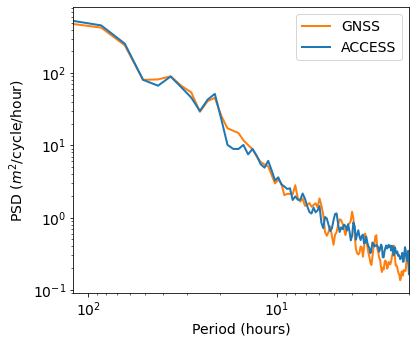

In [38]:
### Plot the PSD

fig, ax = plt.subplots(1, figsize=(6, 5))
ax.loglog(1/freq, GNSS_psd, c='C1', lw=2, label='GNSS')
ax.loglog(1/freq, ACCESS_psd, c='C0', lw=2, label='ACCESS')
ax.invert_xaxis()
ax.set_ylabel('PSD ($m^2$/cycle/hour)')
ax.set_xlabel('Period (hours)')
ax.set_xlim(120, 2)
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
### Calculate the coherence

# Coherence for ACCESS
f_co_a_sn40, Cxy_a_sn40 = scipy.signal.coherence(ACCESS[0, :], GNSS[0, :], fs=1/sam_int, window='hanning', detrend='constant', nperseg=256)
f_co_a_sn20, Cxy_a_sn20 = scipy.signal.coherence(ACCESS[1, :], GNSS[1, :], fs=1/sam_int, window='hanning', detrend='constant', nperseg=256)
f_co_a_sn06, Cxy_a_sn06 = scipy.signal.coherence(ACCESS[2, :], GNSS[2, :], fs=1/sam_int, window='hanning', detrend='constant', nperseg=256)
f_co_a_ss05, Cxy_a_ss05 = scipy.signal.coherence(ACCESS[3, :], GNSS[3, :], fs=1/sam_int, window='hanning', detrend='constant', nperseg=256)
f_co_a_ss20, Cxy_a_ss20 = scipy.signal.coherence(ACCESS[4, :], GNSS[4, :], fs=1/sam_int, window='hanning', detrend='constant', nperseg=256)
f_co_a_ss30, Cxy_a_ss30 = scipy.signal.coherence(ACCESS[5, :], GNSS[5, :], fs=1/sam_int, window='hanning', detrend='constant', nperseg=256)
f_co_a_ss40, Cxy_a_ss40 = scipy.signal.coherence(ACCESS[6, :], GNSS[6, :], fs=1/sam_int, window='hanning', detrend='constant', nperseg=256)
f_co_a_swxt, Cxy_a_swxt = scipy.signal.coherence(ACCESS[7, :], GNSS[7, :], fs=1/sam_int, window='hanning', detrend='constant', nperseg=256)
f_co_a_sext, Cxy_a_sext = scipy.signal.coherence(ACCESS[8, :], GNSS[8, :], fs=1/sam_int, window='hanning', detrend='constant', nperseg=256)

# Mean coherence for ACCESS
f_co_a = f_co_a_sn40
Cxy_a = np.nanmean([Cxy_a_sn40, Cxy_a_sn20, Cxy_a_sn06, Cxy_a_ss05, Cxy_a_ss20, Cxy_a_ss30, Cxy_a_ss40, Cxy_a_swxt, Cxy_a_sext], axis=0)


/tmp/ipykernel_3575562/3167988491.py:4: RuntimeWarning: divide by zero encountered in true_divide
  ax.semilogx(1/f_co_a, Cxy_a, c='C0', lw=2, label='ACCESS')


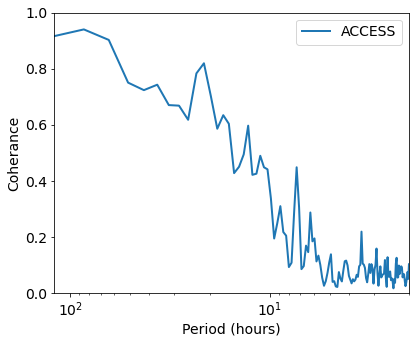

In [41]:
### Plot the coherance

fig, ax = plt.subplots(1, figsize=(6, 5))
ax.semilogx(1/f_co_a, Cxy_a, c='C0', lw=2, label='ACCESS')
ax.invert_xaxis()
ax.set_ylabel('Coherance')
ax.set_xlabel('Period (hours)')
ax.set_xlim(120, 2)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [43]:
### remove 1.5* IQR outliers and calculate RMSE

diff = (ACCESS-GNSS).flatten()

q1 = np.nanpercentile(diff, 25)
q3 = np.nanpercentile(diff, 75)
IQR = q3-q1
diff_median = np.nanmedian(diff)
diff_clean = diff[(diff < (1.5 * IQR + diff_median)) & (diff > (diff_median - 1.5 * IQR))]

print("percentage outliers: %0.1f " % (100*(1-(len(diff_clean[~np.isnan(diff_clean)])/len(diff[~np.isnan(diff)])))))
print('count all, clean: %d, %d' % (len(diff[~np.isnan(diff)]), len(diff_clean[~np.isnan(diff_clean)])))

print('RMSE: %0.1f cm' % (np.nanmean(diff_clean**2)))


percentage outliers: 9.8 
count all, clean: 19656, 17735
RMSE: 0.8 cm
